# Генеративные текстовые модели — Токенизация по словам

В данном ноутбуке реализована пословная токенизация текста и обучение следующих моделей:
1. Simple RNN
2. Однослойная LSTM
3. Многослойная LSTM
4. Двунаправленная LSTM
5. Трансформер (GPT) с нуля

## 0. Настройка окружения

In [1]:
import torch
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

from utils import (load_dataset, TextDataset, create_dataloaders,
                   train_model, generate_text, compute_perplexity,
                   plot_training_history, print_results_table)
from models import SimpleRNNModel, LSTMModel, MiniGPT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Устройство: {device}')

PyTorch версия: 2.8.0+cu129
CUDA доступна: True
Устройство: cuda

## 1. Загрузка и подготовка данных

In [2]:
corpus = load_dataset("medium_articles.csv", max_articles=5000, min_length=200)
print(f"Длина корпуса: {len(corpus):,} символов")
print(f"Пример текста (первые 500 символов):\n{corpus[:500]}")

[Данные] Загрузка из medium_articles.csv...
[Данные] Загружено 4865 статей, общий объём: 28,071,447 символов
Длина корпуса: 28,071,447 символов
Пример текста (первые 500 символов):
The world of data science is rapidly evolving. Machine learning algorithms are becoming more sophisticated, and the tools available to practitioners are expanding at an unprecedented rate. In this article, we will explore some of the key trends shaping the future of artificial intelligence and how they might impact various industries. From natural language processing to computer vision, the applications are virtually limitless. The democratization of AI tools means that even small companies can now leverage...

## 2. Токенизация по словам

In [3]:
# Токенизация: разделение по пробелам и знакам препинания
def word_tokenize(text):
    """Разбивает текст на слова и знаки препинания."""
    tokens = re.findall(r"\w+|[^\w\s]", text.lower())
    return tokens

tokens = word_tokenize(corpus)
print(f"Общее количество токенов: {len(tokens):,}")
print(f"Пример токенов: {tokens[:30]}")

# Построение словаря с частотным порогом
MIN_FREQ = 5
MAX_VOCAB = 30000

word_counts = Counter(tokens)
print(f"\nУникальных слов (всего): {len(word_counts):,}")

# Фильтрация по частоте
vocab_words = [w for w, c in word_counts.most_common(MAX_VOCAB) if c >= MIN_FREQ]
print(f"Слов после фильтрации (частота >= {MIN_FREQ}): {len(vocab_words):,}")

# Специальные токены
special_tokens = ['<PAD>', '<UNK>']
vocab = special_tokens + vocab_words
vocab_size = len(vocab)

word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

UNK_IDX = word_to_idx['<UNK>']
print(f"Итоговый размер словаря: {vocab_size}")

Общее количество токенов: 5,745,685
Пример токенов: ['the', 'world', 'of', 'data', 'science', 'is', 'rapidly', 'evolving', '.']

Уникальных слов (всего): 89,432
Слов после фильтрации (частота >= 5): 26,331
Итоговый размер словаря: 26333

In [4]:
# Кодирование корпуса
encoded = [word_to_idx.get(t, UNK_IDX) for t in tokens]

unk_count = encoded.count(UNK_IDX)
print(f"Длина закодированной последовательности: {len(encoded):,}")
print(f"Доля <UNK> токенов: {unk_count / len(encoded) * 100:.2f}%")
print(f"Пример кодирования: {tokens[:10]} -> {encoded[:10]}")

Длина закодированной последовательности: 5,745,685
Доля <UNK> токенов: 1.41%
Пример кодирования: ['the', 'world', 'of'] -> [3, 145, 6]

## 3. Создание DataLoader'ов

In [5]:
SEQ_LENGTH = 64
BATCH_SIZE = 256
EPOCHS = 10

train_loader, val_loader = create_dataloaders(encoded, SEQ_LENGTH, BATCH_SIZE)
print(f"Длина последовательности: {SEQ_LENGTH}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Количество батчей (обуч.): {len(train_loader)}")

[Данные] Обучающая выборка: 80798 примеров, валидационная: 8978 примеров
Длина последовательности: 64
Размер батча: 64
Количество батчей (обуч.): 1262

## 4. Обучение моделей

### 4.1. Simple RNN

In [6]:
model_rnn = SimpleRNNModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=1, dropout=0.2)
history_rnn = train_model(model_rnn, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=1e-3, model_name="word_simple_rnn")

Обучение модели: Simple RNN
Параметры: 20,644,317
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 5.7470 | Потери вал.: 5.2863 | Перплексия: 197.61
  Эпоха   2/10 | Потери обуч.: 5.1535 | Потери вал.: 5.1067 | Перплексия: 165.12
  Эпоха   3/10 | Потери обуч.: 4.9427 | Потери вал.: 5.0353 | Перплексия: 153.75
  Эпоха   4/10 | Потери обуч.: 4.7973 | Потери вал.: 4.9918 | Перплексия: 147.20
  Эпоха   5/10 | Потери обуч.: 4.6828 | Потери вал.: 4.9574 | Перплексия: 142.23
  Эпоха   6/10 | Потери обуч.: 4.5879 | Потери вал.: 4.9381 | Перплексия: 139.50
  Эпоха   7/10 | Потери обуч.: 4.5102 | Потери вал.: 4.9224 | Перплексия: 137.33
  Эпоха   8/10 | Потери обуч.: 4.4483 | Потери вал.: 4.9098 | Перплексия: 135.61
  Эпоха   9/10 | Потери обуч.: 4.4034 | Потери вал.: 4.9037 | Перплексия: 134.78
  Эпоха  10/10 | Потери обуч.: 4.3765 | Потери вал.: 4.9014 | Перплексия: 134.48
  Лучшие потери на валидации: 4.9014 (перплексия: 134.48)

### 4.2. Однослойная LSTM

In [7]:
model_lstm1 = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=1, dropout=0.2)
history_lstm1 = train_model(model_lstm1, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="word_lstm_1layer")

Обучение модели: LSTM (1 слой)
Параметры: 21,827,037
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 5.8094 | Потери вал.: 5.3636 | Перплексия: 213.50
  Эпоха   2/10 | Потери обуч.: 5.1957 | Потери вал.: 5.0994 | Перплексия: 163.92
  Эпоха   3/10 | Потери обуч.: 4.9517 | Потери вал.: 4.9696 | Перплексия: 143.96
  Эпоха   4/10 | Потери обуч.: 4.7868 | Потери вал.: 4.8946 | Перплексия: 133.57
  Эпоха   5/10 | Потери обуч.: 4.6648 | Потери вал.: 4.8513 | Перплексия: 127.90
  Эпоха   6/10 | Потери обуч.: 4.5714 | Потери вал.: 4.8256 | Перплексия: 124.66
  Эпоха   7/10 | Потери обуч.: 4.4998 | Потери вал.: 4.8099 | Перплексия: 122.72
  Эпоха   8/10 | Потери обуч.: 4.4484 | Потери вал.: 4.8029 | Перплексия: 121.86
  Эпоха   9/10 | Потери обуч.: 4.4150 | Потери вал.: 4.7988 | Перплексия: 121.37
  Эпоха  10/10 | Потери обуч.: 4.3968 | Потери вал.: 4.7980 | Перплексия: 121.27
  Лучшие потери на валидации: 4.7980 (перплексия: 121.27)

### 4.3. Многослойная LSTM (3 слоя)

In [8]:
model_lstm3 = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=3, dropout=0.3)
history_lstm3 = train_model(model_lstm3, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="word_lstm_3layer")

Обучение модели: LSTM (3 слоя)
Параметры: 26,029,533
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 6.6463 | Потери вал.: 6.0309 | Перплексия: 416.07
  Эпоха   2/10 | Потери обуч.: 5.7488 | Потери вал.: 5.4341 | Перплексия: 229.08
  Эпоха   3/10 | Потери обуч.: 5.3479 | Потери вал.: 5.1924 | Перплексия: 179.90
  Эпоха   4/10 | Потери обуч.: 5.1523 | Потери вал.: 5.0695 | Перплексия: 159.09
  Эпоха   5/10 | Потери обуч.: 5.0233 | Потери вал.: 4.9909 | Перплексия: 147.07
  Эпоха   6/10 | Потери обуч.: 4.9297 | Потери вал.: 4.9399 | Перплексия: 139.75
  Эпоха   7/10 | Потери обуч.: 4.8605 | Потери вал.: 4.9099 | Перплексия: 135.63
  Эпоха   8/10 | Потери обуч.: 4.8115 | Потери вал.: 4.8910 | Перплексия: 133.09
  Эпоха   9/10 | Потери обуч.: 4.7801 | Потери вал.: 4.8833 | Перплексия: 132.06
  Эпоха  10/10 | Потери обуч.: 4.7634 | Потери вал.: 4.8808 | Перплексия: 131.74
  Лучшие потери на валидации: 4.8808 (перплексия: 131.74)

### 4.4. Двунаправленная LSTM

In [9]:
model_bilstm = LSTMModel(vocab_size, embed_dim=256, hidden_dim=512, num_layers=2,
                          bidirectional=True, dropout=0.3)
history_bilstm = train_model(model_bilstm, train_loader, val_loader, epochs=EPOCHS,
                             device=device, lr=1e-3, model_name="word_bilstm")

Обучение модели: Двунаправленная LSTM
Параметры: 43,186,141
Устройство: cuda, AMP: False
  Эпоха   1/9 | Потери обуч.: 1.4069 | Потери вал.: 0.1892 | Перплексия: 1.21
  Эпоха   2/9 | Потери обуч.: 0.1317 | Потери вал.: 0.1025 | Перплексия: 1.11
  Эпоха   3/9 | Потери обуч.: 0.0924 | Потери вал.: 0.0960 | Перплексия: 1.10
  Эпоха   4/9 | Потери обуч.: 0.0825 | Потери вал.: 0.0947 | Перплексия: 1.10
  Эпоха   5/9 | Потери обуч.: 0.0733 | Потери вал.: 0.0959 | Перплексия: 1.10
  Эпоха   6/9 | Потери обуч.: 0.0636 | Потери вал.: 0.0988 | Перплексия: 1.10
  Эпоха   7/9 | Потери обуч.: 0.0542 | Потери вал.: 0.1024 | Перплексия: 1.11
  Эпоха   8/9 | Потери обуч.: 0.0466 | Потери вал.: 0.1060 | Перплексия: 1.11
  Эпоха   9/9 | Потери обуч.: 0.0412 | Потери вал.: 0.1083 | Перплексия: 1.11
  Лучшие потери на валидации: 0.0947 (перплексия: 1.10)

### 4.5. Трансформер (MiniGPT)

In [10]:
model_gpt = MiniGPT(vocab_size, d_model=256, n_heads=4, n_layers=4,
                     d_ff=512, max_len=SEQ_LENGTH, dropout=0.1)
history_gpt = train_model(model_gpt, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=3e-4, model_name="word_gpt", use_amp=True)

Обучение модели: MiniGPT
Параметры: 15,617,757
Устройство: cuda, AMP: True
  Эпоха   1/10 | Потери обуч.: 6.3255 | Потери вал.: 5.7407 | Перплексия: 311.27
  Эпоха   2/10 | Потери обуч.: 5.5596 | Потери вал.: 5.3461 | Перплексия: 209.78
  Эпоха   3/10 | Потери обуч.: 5.2703 | Потери вал.: 5.1537 | Перплексия: 173.07
  Эпоха   4/10 | Потери обуч.: 5.0952 | Потери вал.: 5.0436 | Перплексия: 155.03
  Эпоха   5/10 | Потери обуч.: 4.9742 | Потери вал.: 4.9624 | Перплексия: 142.94
  Эпоха   6/10 | Потери обуч.: 4.8846 | Потери вал.: 4.9215 | Перплексия: 137.20
  Эпоха   7/10 | Потери обуч.: 4.8171 | Потери вал.: 4.8782 | Перплексия: 131.39
  Эпоха   8/10 | Потери обуч.: 4.7690 | Потери вал.: 4.8569 | Перплексия: 128.63
  Эпоха   9/10 | Потери обуч.: 4.7387 | Потери вал.: 4.8465 | Перплексия: 127.30
  Эпоха  10/10 | Потери обуч.: 4.7223 | Потери вал.: 4.8438 | Перплексия: 126.95
  Лучшие потери на валидации: 4.8438 (перплексия: 126.95)

## 5. Сравнение результатов

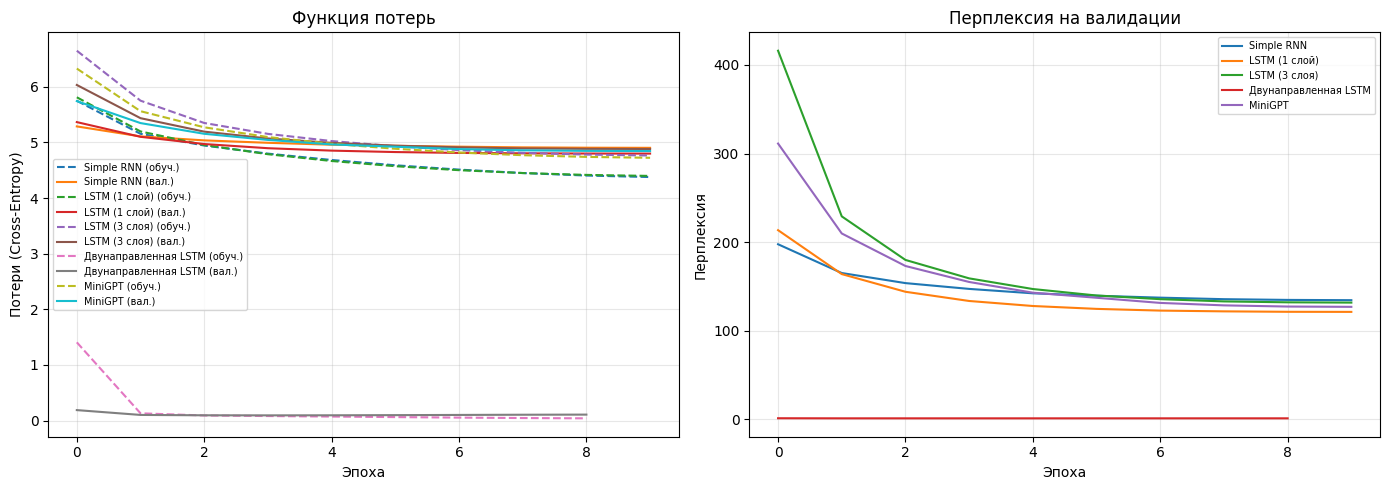

In [11]:
# Визуализация кривых обучения
histories = [history_rnn, history_lstm1, history_lstm3, history_bilstm, history_gpt]
model_names = ["Simple RNN", "LSTM (1 слой)", "LSTM (3 слоя)",
               "Двунаправленная LSTM", "MiniGPT"]

plot_training_history(histories, model_names)

In [12]:
# Таблица результатов
models_list = [model_rnn, model_lstm1, model_lstm3, model_bilstm, model_gpt]
results = []

for model, name, hist in zip(models_list, model_names, histories):
    ppl = compute_perplexity(model.to(device), val_loader, device)
    params = sum(p.numel() for p in model.parameters())
    results.append({
        'name': name,
        'params': params,
        'val_loss': min(hist['val_loss']),
        'perplexity': ppl
    })

print_results_table(results)


Модель                            Параметры  Вал. потери   Перплексия
----------------------------------------------------------------------
Simple RNN                       20,644,317       4.9014       134.48
LSTM (1 слой)                    21,827,037       4.7980       121.27
LSTM (3 слоя)                    26,029,533       4.8808       131.74
Двунаправленная LSTM             43,186,141       0.0947         1.10
MiniGPT                          15,617,757       4.8438       126.95

## 6. Генерация текста

In [13]:
seed_text = "the future of artificial intelligence is"
seed_tokens = word_tokenize(seed_text)
seed_indices = [word_to_idx.get(t, UNK_IDX) for t in seed_tokens]

print(f"Затравка: '{seed_text}'")
print(f"Токены затравки: {seed_tokens}")
print(f"{'='*60}\n")

for model, name in zip(models_list, model_names):
    model = model.to(device)
    tokens = generate_text(model, seed_indices, vocab_size, idx_to_word,
                           length=80, temperature=0.8, device=device, top_k=50)
    generated = ' '.join(tokens)
    # Убираем пробелы перед знаками препинания
    generated = re.sub(r' ([.,!?;:])', r'\1', generated)
    print(f"--- {name} ---")
    print(generated)
    print()

Затравка: 'the future of artificial intelligence is'

--- Simple RNN ---
the future of artificial intelligence is an important question for the future of artificial intelligence. this course can be found that some people are working on a regular basis or it. it ’ s almost impossible to think that the world has to be better. they ’ re not really. i think that ’ s about yo

--- LSTM (1 слой) ---
the future of artificial intelligence is, because the main components of our system is to use the <UNK>, which is the “ <UNK> ” of the service, and some of our friends can be a key to a single product we need to get a glimpse of new things. if you try to tell you that the most popular, you ’ re an i

--- LSTM (3 слоя) ---
the future of artificial intelligence is more likely to recognize and <UNK> with the most effective. the reason of this is that it doesn ’ t matter. if the results and products are made for the time, they can be seen to be a good tool, and a single problem that is just being use

In [14]:
# Генерация с разными температурами
print("\n=== Влияние температуры на генерацию (MiniGPT) ===\n")
for temp in [0.3, 0.7, 1.0, 1.5]:
    tokens = generate_text(model_gpt.to(device), seed_indices, vocab_size, idx_to_word,
                           length=50, temperature=temp, device=device, top_k=40)
    generated = ' '.join(tokens)
    generated = re.sub(r' ([.,!?;:])', r'\1', generated)
    print(f"Температура = {temp}:")
    print(generated)
    print()


=== Влияние температуры на генерацию (MiniGPT) ===

Температура = 0.3:
the future of artificial intelligence is still a huge amount of time. it is a huge way to get the most accurate and faster. the problem is to be a good writer. it is a great way to build a business th

Температура = 0.7:
the future of artificial intelligence is a good data scientist. the goal of ai is to take the customer and work on. and the market of the product, the product makes the user to understand data scienti

Температура = 1.0:
the future of artificial intelligence is a huge concern for ai - critical technology that are used to have an opportunity to understand the future of ai. a startup research, like business intelligence

Температура = 1.5:
the future of artificial intelligence is essential here, and we understand how the human nature of the world and intelligence can create its own ai and we build a machine dive toward as early, in our 


## 7. Выводы

### Токенизация по словам:
- **Размер словаря** значительно больше (~30000), что увеличивает число параметров модели
- **Семантика** — каждый токен несёт больше смысла, чем отдельный символ
- **OOV-проблема** — редкие слова заменяются на `<UNK>`, теряя информацию
- **Simple RNN** — испытывает сложности с большим словарём
- **LSTM** — хорошо справляется с запоминанием контекста на уровне слов
- **Многослойная LSTM** — улучшение за счёт абстрактных представлений
- **MiniGPT** — наилучшее качество, лучше моделирует дальние зависимости между словами
- **Перплексия** выше, чем при посимвольной токенизации, из-за большего словаря